#### Import Modules 

In [11]:
import sys
sys.path.append('..')
from src.stock_data_loader import load_stock, fix_dtypes, handle_missing
from src.indicators import (
    add_moving_averages, add_rsi, add_macd, print_signals, print_financial_metrics
)
from src.visualizations import plot_all_indicators

####  Technical analysis pipeline for AAPL

 LOAD AND CLEAN DATA

In [12]:
ticker = 'AAPL'
df = load_stock(ticker)
df = fix_dtypes(df)
df = handle_missing(df)

print(f"Data: {len(df)} rows")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Data: 3774 rows
Date range: 2009-01-02 to 2023-12-29


ADD TECHNICAL INDICATORS

In [15]:

df = add_moving_averages(df)
df = add_rsi(df)
df = add_macd(df)

# VIEW LATEST VALUES

print("\n" + "=" * 60)
print("LATEST VALUES (Last 5 days)")
print("=" * 60)
print(df[['Date', 'Close', 'SMA_20', 'SMA_50', 'RSI', 'MACD', 'MACD_signal']].tail(5).to_string())


LATEST VALUES (Last 5 days)
           Date       Close      SMA_20      SMA_50        RSI      MACD  MACD_signal
3769 2023-12-22  191.788757  191.856618  183.572859  54.672784  2.633141     3.235256
3770 2023-12-26  191.243912  192.018094  183.858864  53.090049  2.304751     3.049155
3771 2023-12-27  191.342972  192.154308  184.149424  53.354446  2.029104     2.845145
3772 2023-12-28  191.768951  192.362839  184.479567  54.540999  1.823998     2.640915
3773 2023-12-29  190.728775  192.490633  184.814828  51.121347  1.559539     2.424640


GET TRADING SIGNALS

In [16]:
print_signals(df, ticker)


 MOVING AVERAGE FOR AAPL:
   Trend: UPTREND
   Action: HOLD

 RSI FOR AAPL:
   Status: NEUTRAL
   Action: HOLD

 MACD FOR AAPL:
   Momentum: BEARISH
   Action: HOLD


In [17]:
print_financial_metrics(df, 'AAPL')


FINANCIAL METRICS: AAPL
Total Return:      6907.7%
Volatility:        28.6%
Max Drawdown:      -43.8%
Sharpe Ratio:      1.07



##################################################
TECHNICAL ANALYSIS: AAPL
##################################################

 PLOT 1: Price Chart with Moving Averages


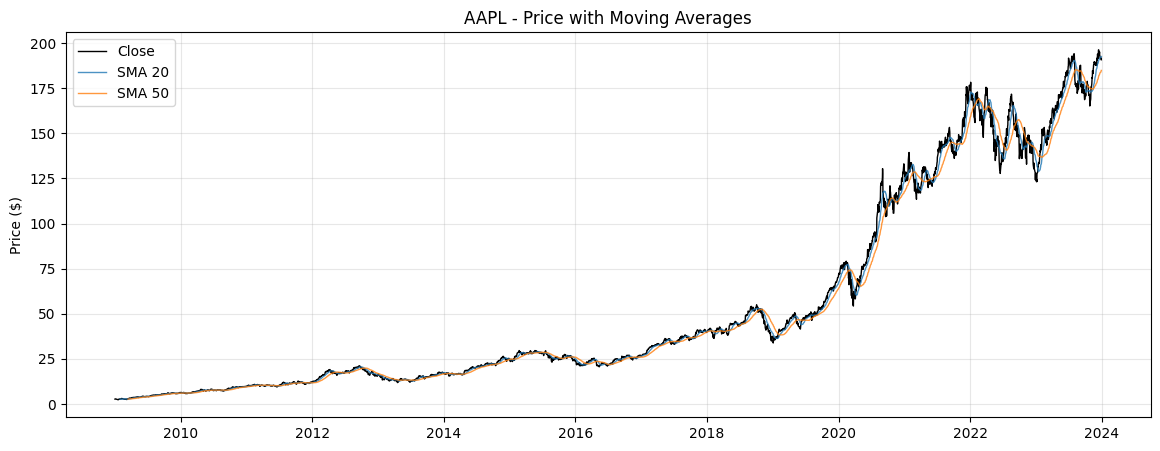


 PLOT 2: RSI (Relative Strength Index)


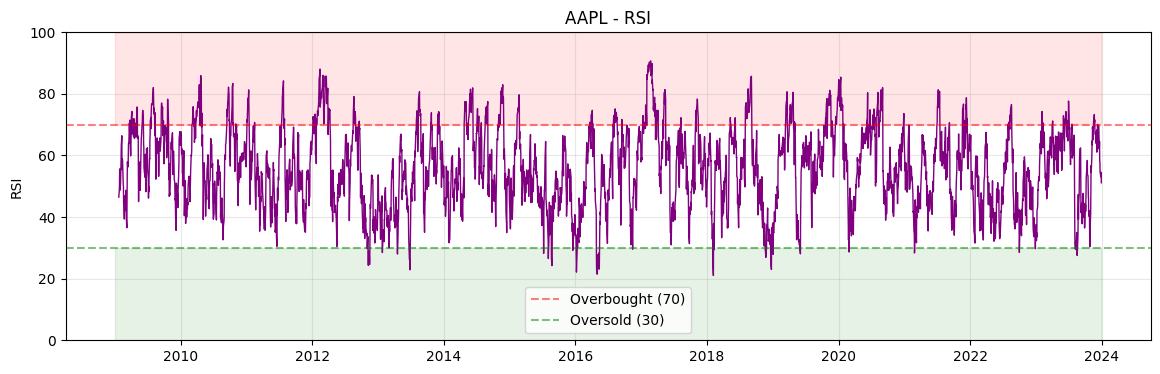


 PLOT for MACD (Moving Average Convergence Divergence)


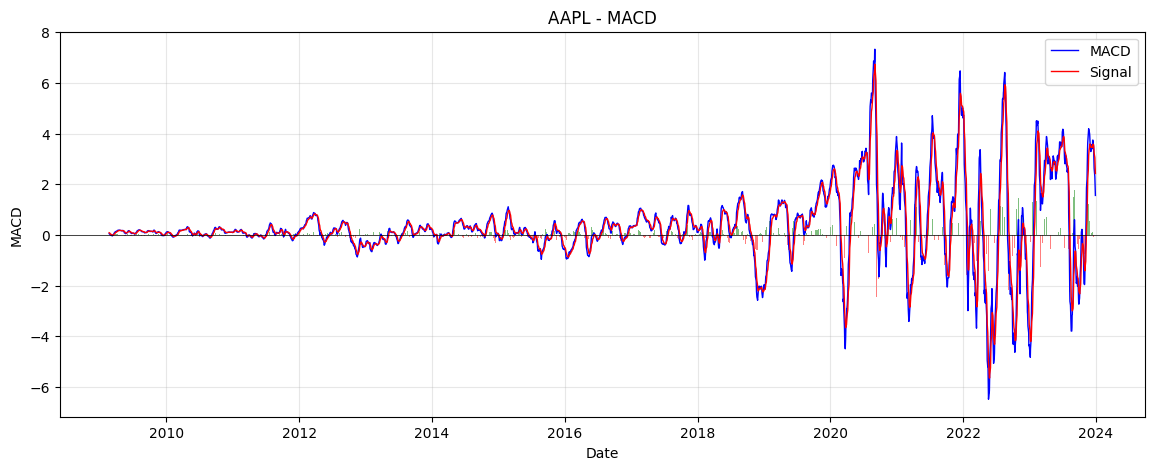

In [18]:
plot_all_indicators(df, ticker)